In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

np.random.seed(42)

# Parameters
num_users = 50
transactions_per_user = 40
merchant_categories = ["Food", "Shopping", "Entertainment", "Travel", "Grocery", "Transport"]

data = []

for user in range(1, num_users + 1):
    avg_daily_spend = random.randint(800, 2000)

    for t in range(transactions_per_user):
        date = datetime(2024, 2, 1) + timedelta(days=random.randint(0, 27))
        time_hour = random.choice(range(8, 24))
        minute = random.choice([0, 15, 30, 45])

        amount = np.random.normal(avg_daily_spend / 3, avg_daily_spend / 2)
        amount = max(100, int(amount))

        late_night = 1 if time_hour >= 22 else 0
        is_weekend = 1 if date.weekday() >= 5 else 0
        is_end_of_month = 1 if date.day >= 25 else 0

        transactions_today = random.randint(1, 7)
        spend_deviation = amount - avg_daily_spend

        impulse_label = 1 if (
            late_night == 1 and
            spend_deviation > 500 and
            transactions_today >= 4
        ) else 0

        data.append([
            f"U{user:03}",
            f"T{user}{t:03}",
            date.date(),
            f"{time_hour:02}:{minute:02}",
            amount,
            random.choice(merchant_categories),
            date.strftime("%A"),
            is_weekend,
            is_end_of_month,
            transactions_today,
            avg_daily_spend,
            spend_deviation,
            late_night,
            impulse_label
        ])

columns = [
    "user_id",
    "transaction_id",
    "transaction_date",
    "transaction_time",
    "amount",
    "merchant_category",
    "day_of_week",
    "is_weekend",
    "is_end_of_month",
    "transactions_today",
    "avg_daily_spend",
    "spend_deviation",
    "late_night",
    "impulse_label"
]

df = pd.DataFrame(data, columns=columns)

# Save dataset
df.to_csv("synthetic_impulse_spending_data.csv", index=False)

df.head()

,user_id,transaction_id,transaction_date,transaction_time,amount,merchant_category,day_of_week,is_weekend,is_end_of_month,transactions_today,avg_daily_spend,spend_deviation,late_night,impulse_label
0,U001,T1000,2024-02-15,16:15,969,Travel,Thursday,0,0,4,1667,-698,0,0
1,U001,T1001,2024-02-01,08:45,440,Shopping,Thursday,0,0,1,1667,-1227,0,0
2,U001,T1002,2024-02-28,17:15,1095,Entertainment,Wednesday,0,1,3,1667,-572,0,0
3,U001,T1003,2024-02-24,11:30,1825,Grocery,Saturday,1,0,7,1667,158,0,0
4,U001,T1004,2024-02-28,19:00,360,Shopping,Wednesday,0,1,2,1667,-1307,0,0


In [ ]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

FEATURE ENGINEERING

In [ ]:
df["high_spend"] = df["spend_deviation"].apply(lambda x: 1 if x > 500 else 0)
df["frequent_spender"] = df["transactions_today"].apply(lambda x: 1 if x >= 4 else 0)

features = [
    "amount", "late_night", "is_weekend",
    "is_end_of_month", "transactions_today",
    "high_spend", "frequent_spender"
]

X = df[features]
y = df["impulse_label"]

TRAIN ML MODEL (LOGISTIC REGRESSION)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.998
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       498
           1       0.67      1.00      0.80         2

    accuracy                           1.00       500
   macro avg       0.83      1.00      0.90       500
weighted avg       1.00      1.00      1.00       500



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


IMPULSE RISK SCORE (CORE OUTPUT)

In [ ]:
def calculate_impulse_score(row):
    score = 0

    if row["late_night"] == 1:
        score += 20
    if row["high_spend"] == 1:
        score += 25
    if row["frequent_spender"] == 1:
        score += 20
    if row["is_end_of_month"] == 1:
        score += 20
    if row["is_weekend"] == 1:
        score += 15

    return min(score, 100)

df["impulse_risk_score"] = df.apply(calculate_impulse_score, axis=1)

BEHAVIOUR PROFILE CLASSIFICATION

In [ ]:
def behaviour_profile(row):
    if row["late_night"] and row["high_spend"]:
        return "Late-night Emotional Spender"
    elif row["is_weekend"] and row["frequent_spender"]:
        return "Weekend Impulse Spender"
    elif row["is_end_of_month"] and row["high_spend"]:
        return "End-of-Month Overspender"
    else:
        return "Controlled Spender"

df["behaviour_profile"] = df.apply(behaviour_profile, axis=1)

PERSONALIZED BEHAVIOURAL NUDGES

In [ ]:
def generate_nudge(row):
    if row["behaviour_profile"] == "Late-night Emotional Spender":
        return "Avoid making purchases after 10 PM to reduce impulsive spending."
    elif row["behaviour_profile"] == "Weekend Impulse Spender":
        return "Plan weekend expenses in advance to stay within budget."
    elif row["behaviour_profile"] == "End-of-Month Overspender":
        return "Track monthly budget closely near month-end."
    else:
        return "Great job managing your spending habits!"

df["behavioural_nudge"] = df.apply(generate_nudge, axis=1)

FINAL OUTPUT SAMPLE (WHAT JUDGES WILL SEE)

In [ ]:
df[[
    "user_id",
    "amount",
    "impulse_risk_score",
    "behaviour_profile",
    "behavioural_nudge"
]].head(10)

,user_id,amount,impulse_risk_score,behaviour_profile,behavioural_nudge
0,U001,969,20,Controlled Spender,Great job managing your spending habits!
1,U001,440,0,Controlled Spender,Great job managing your spending habits!
2,U001,1095,20,Controlled Spender,Great job managing your spending habits!
3,U001,1825,35,Weekend Impulse Spender,Plan weekend expenses in advance to stay withi...
4,U001,360,20,Controlled Spender,Great job managing your spending habits!
5,U001,360,55,Weekend Impulse Spender,Plan weekend expenses in advance to stay withi...
6,U001,1871,0,Controlled Spender,Great job managing your spending habits!
7,U001,1195,0,Controlled Spender,Great job managing your spending habits!
8,U001,164,0,Controlled Spender,Great job managing your spending habits!
9,U001,1007,35,Weekend Impulse Spender,Plan weekend expenses in advance to stay withi...


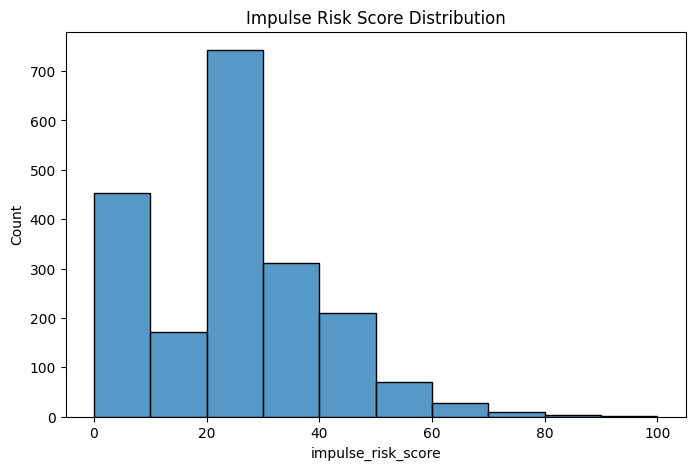

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["impulse_risk_score"], bins=10)
plt.title("Impulse Risk Score Distribution")
plt.show()

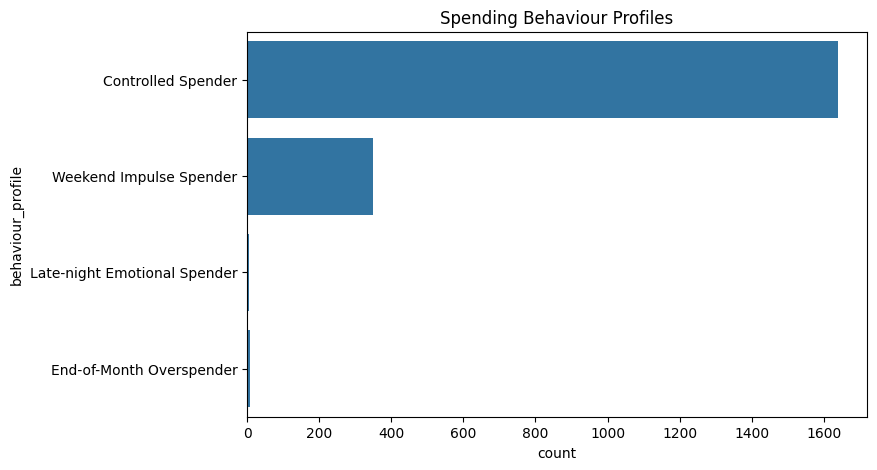

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(y=df["behaviour_profile"])
plt.title("Spending Behaviour Profiles")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

/tmp/ipython-input-381/1494374335.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


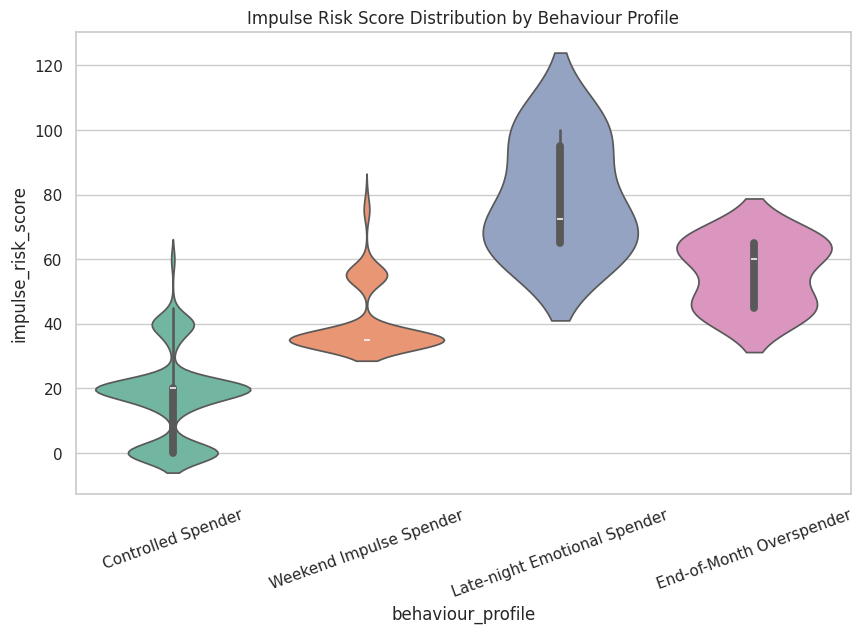

In [ ]:
sns.violinplot(
    data=df,
    x="behaviour_profile",
    y="impulse_risk_score",
    palette="Set2"
)
plt.title("Impulse Risk Score Distribution by Behaviour Profile")
plt.xticks(rotation=20)
plt.show()

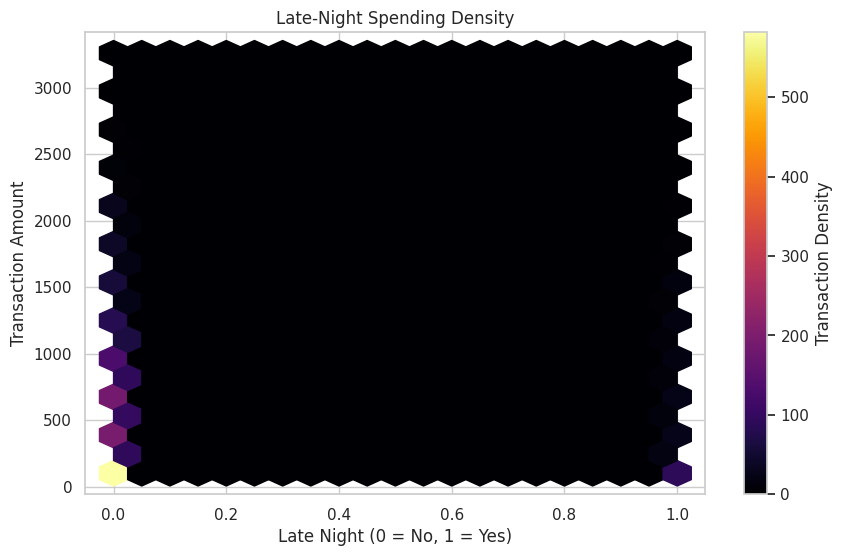

In [ ]:
plt.hexbin(
    df["late_night"],
    df["amount"],
    gridsize=20,
    cmap="inferno"
)
plt.colorbar(label="Transaction Density")
plt.xlabel("Late Night (0 = No, 1 = Yes)")
plt.ylabel("Transaction Amount")
plt.title("Late-Night Spending Density")
plt.show()

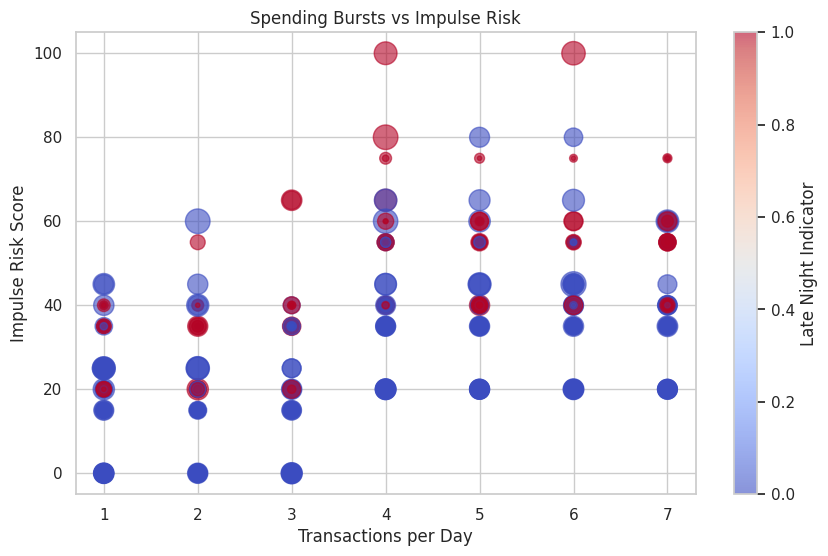

In [ ]:
plt.scatter(
    df["transactions_today"],
    df["impulse_risk_score"],
    s=df["amount"]/10,
    alpha=0.6,
    c=df["late_night"],
    cmap="coolwarm"
)
plt.colorbar(label="Late Night Indicator")
plt.xlabel("Transactions per Day")
plt.ylabel("Impulse Risk Score")
plt.title("Spending Bursts vs Impulse Risk")
plt.show()

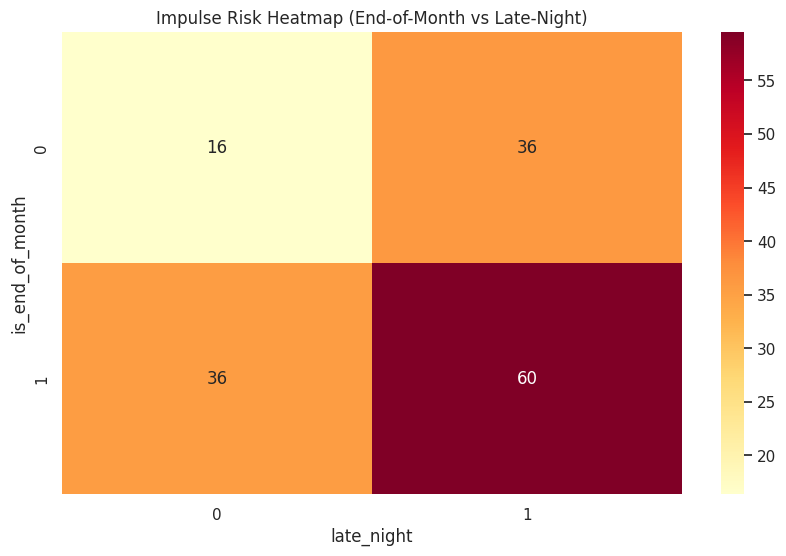

In [ ]:
heatmap_data = df.groupby(
    ["is_end_of_month", "late_night"]
)["impulse_risk_score"].mean().unstack()

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlOrRd"
)
plt.title("Impulse Risk Heatmap (End-of-Month vs Late-Night)")
plt.show()

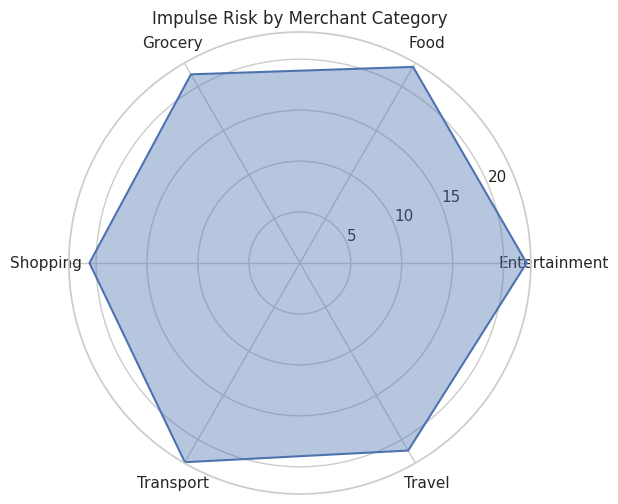

In [ ]:
category_score = df.groupby("merchant_category")["impulse_risk_score"].mean()

angles = np.linspace(0, 2*np.pi, len(category_score), endpoint=False)
values = category_score.values
angles = np.concatenate([angles, [angles[0]]])
values = np.concatenate([values, [values[0]]])

plt.polar(angles, values)
plt.fill(angles, values, alpha=0.4)
plt.xticks(angles[:-1], category_score.index)
plt.title("Impulse Risk by Merchant Category")
plt.show()

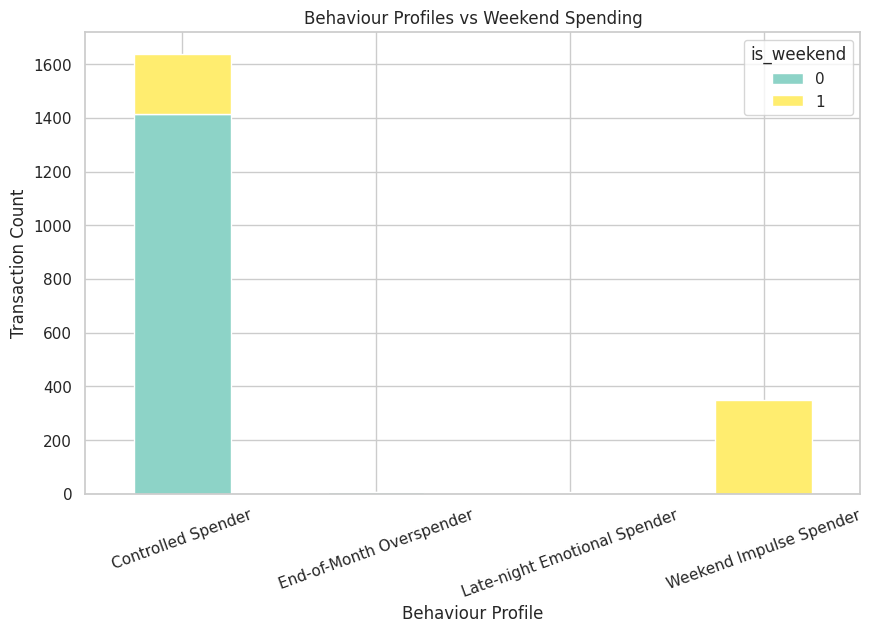

In [ ]:
stack_data = pd.crosstab(df["behaviour_profile"], df["is_weekend"])
stack_data.plot(kind="bar", stacked=True, colormap="Set3")

plt.title("Behaviour Profiles vs Weekend Spending")
plt.xlabel("Behaviour Profile")
plt.ylabel("Transaction Count")
plt.xticks(rotation=20)
plt.show()

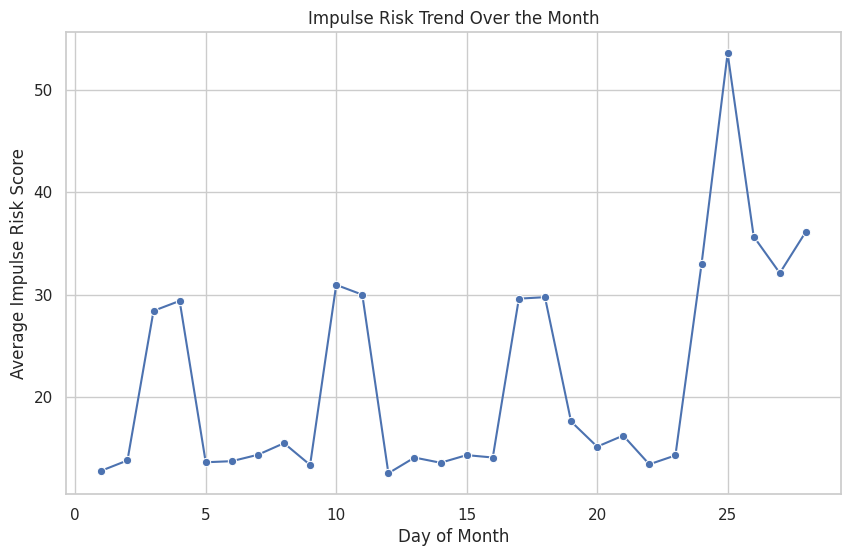

In [ ]:
df["day"] = pd.to_datetime(df["transaction_date"]).dt.day

daily_trend = df.groupby("day")["impulse_risk_score"].mean()

sns.lineplot(x=daily_trend.index, y=daily_trend.values, marker="o")
plt.title("Impulse Risk Trend Over the Month")
plt.xlabel("Day of Month")
plt.ylabel("Average Impulse Risk Score")
plt.show()

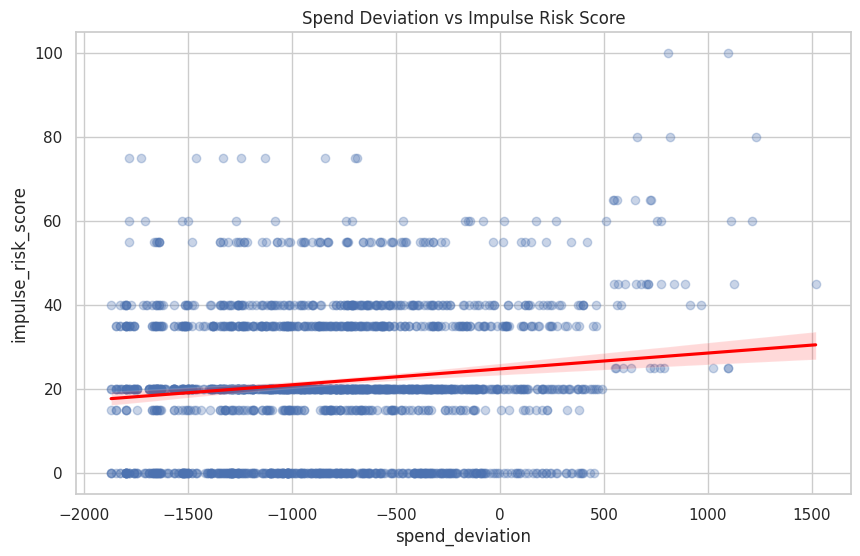

In [ ]:
sns.regplot(
    data=df,
    x="spend_deviation",
    y="impulse_risk_score",
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"}
)
plt.title("Spend Deviation vs Impulse Risk Score")
plt.show()

/tmp/ipython-input-381/3726794999.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(


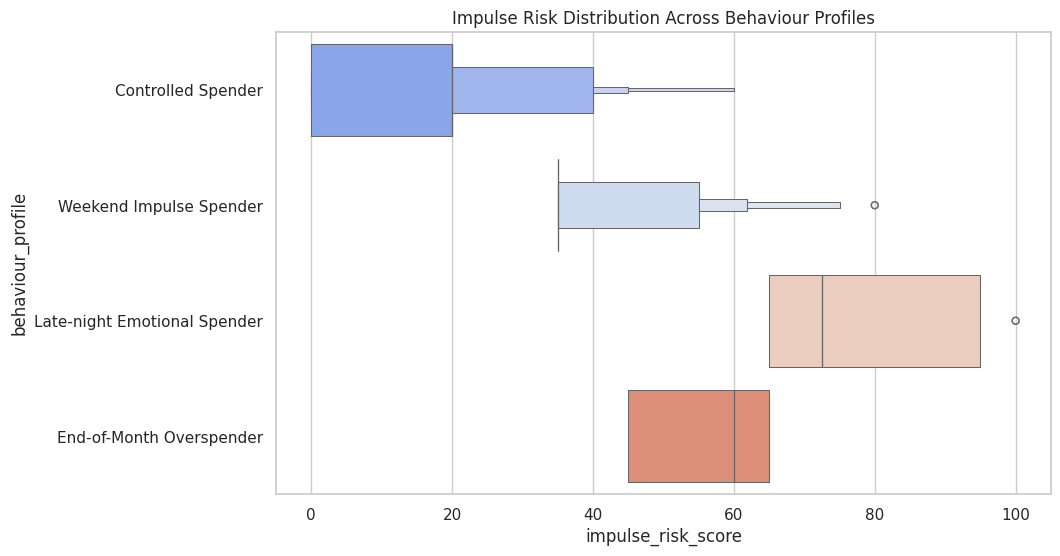

In [ ]:
sns.boxenplot(
    data=df,
    x="impulse_risk_score",
    y="behaviour_profile",
    palette="coolwarm"
)
plt.title("Impulse Risk Distribution Across Behaviour Profiles")
plt.show()

/tmp/ipython-input-381/4095308971.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


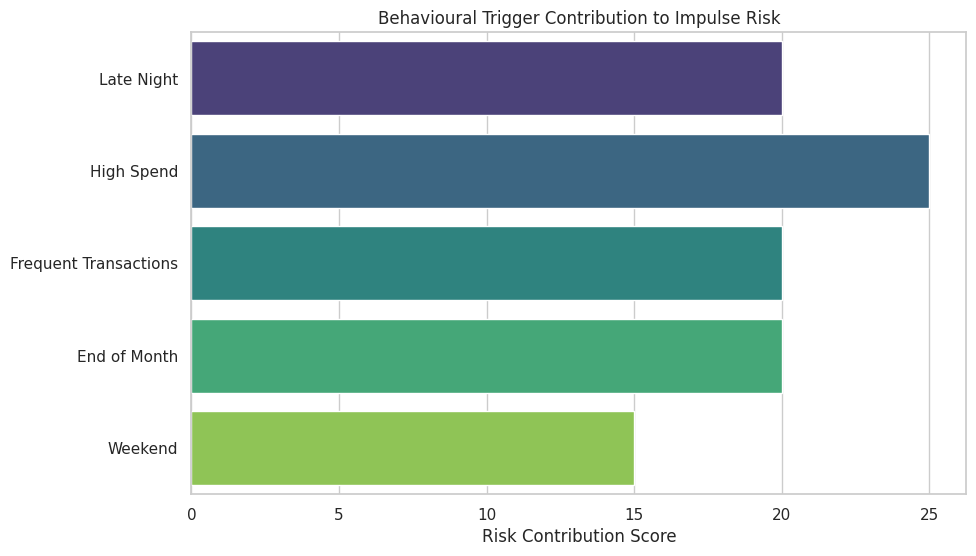

In [ ]:
trigger_impact = {
    "Late Night": 20,
    "High Spend": 25,
    "Frequent Transactions": 20,
    "End of Month": 20,
    "Weekend": 15
}

sns.barplot(
    x=list(trigger_impact.values()),
    y=list(trigger_impact.keys()),
    palette="viridis"
)
plt.title("Behavioural Trigger Contribution to Impulse Risk")
plt.xlabel("Risk Contribution Score")
plt.show()